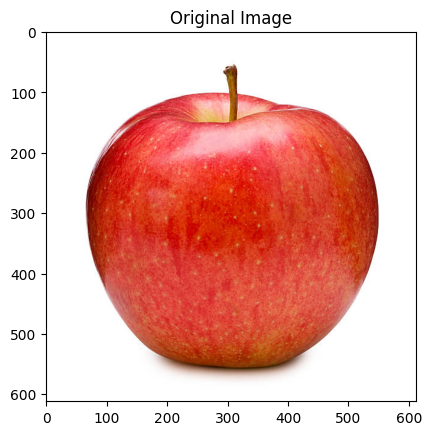

Shape:  (612, 612, 3)
Pixel [0,0] [255 255 255]


In [ ]:
import tensorflow as tf

from PIL import Image # Import Image from Pillow library
import numpy as np # Import numpy (used for math)
import matplotlib.pyplot as plt # import matplotlib (used for visualizations)

img = Image.open('apple.jpg') # Open the image into img variable
plt.imshow(img) # Show the image

plt.title('Original Image')

plt.show()
pixels = np.array(img) # Store image pixels into an array

print('Shape: ', pixels.shape)  # height, width, and 3 color channels
print('Pixel [0,0]', pixels[0,0])

In [ ]:
import zipfile
import os

with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
  zip_ref.extractall('dataset_unzipped/')

print("Dataset unzipped into dataset_unzipped/")

Dataset unzipped into dataset_unzipped/


In [ ]:
# Used for image preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# For building our neural network
from tensorflow.keras import layers, models


In [ ]:
import shutil
import os

src = "dataset_unzipped/dataset"
dst = "dataset_unzipped"

for folder in ["apples", "bananas"]:
  shutil.move(os.path.join(src, folder), os.path.join(dst, folder))

shutil.rmtree(src, ignore_errors=True)

print(os.listdir("dataset_unzipped"))

['apples', 'bananas']


In [ ]:
# Rescales the image from 0-255 to 0-1
datagen = ImageDataGenerator(rescale=1./255)

# Use the generator to load images from our folders
train = datagen.flow_from_directory(
    'dataset_unzipped', # This is the path to the folder
    target_size=(150,150), # Resize the images to 150x150 pixels
    batch_size=1, # One image per batch
    class_mode='binary', # Two classes (apples or bananas)
    shuffle=True # Shuffle the images for each epoch
)

print(os.listdir('dataset_unzipped'))

Found 9 images belonging to 2 classes.
['apples', 'bananas']


In [ ]:
# Configuring the neural network layers

model = models.Sequential([

    layers.Conv2D(8, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(32, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(train, epochs=5) # Train the model with 5 epochs

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
6/9 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.3028 - loss: 1.4810

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.3634 - loss: 1.4311
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7453 - loss: 0.5830
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9510 - loss: 0.3221
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 1.0000 - loss: 0.0987
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 1.0000 - loss: 0.0431


In [ ]:
model.save('fruit_classifier.keras')

In [ ]:
model = tf.keras.models.load_model('fruit_classifier.keras')
test_img = Image.open('test_item_2.jpg').resize((150,150))
x = np.expand_dims(np.array(test_img)/255.0, axis=0)
pred = model.predict(x) # Predict on the test image

print(train.class_indices) # Tells us what our prediction is leaning towards
print(pred[0][0])
if(pred[0][0] > 0.5):
  print('banana')
else:
  print('apple')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
{'apples': 0, 'bananas': 1}
0.765696
banana
